In [ ]:
# Law of Large Numbers 

If we repeat an experiment many times:
    
Experimental probability → theoretical probability

Example:
    
Coin toss simulation.


In [7]:
import numpy as np

flips = np.random.choice(["H","T"], size=10000)

heads = np.sum(flips=="H")

print("Probability of heads:", heads/10000)

Probability of heads: 0.5053


In [ ]:
# Discrete vs Continuous Probability

Discrete Probability

Countable outcomes.
Example:
•	dice
•	cards


Continuous Probability

Infinite possible values.
Example:
•	height
•	temperature



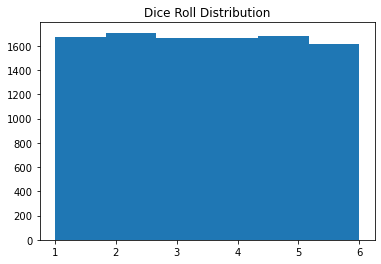

In [8]:
import matplotlib.pyplot as plt
import numpy as np

rolls = np.random.randint(1,7,10000)

plt.hist(rolls, bins=6)
plt.title("Dice Roll Distribution")
plt.show()

In [ ]:
# Do you notice all outcomes approximately equal??? 

In [ ]:
# Statistics → Probability

In [ ]:
| Statistics          | Probability          |
| ------------------- | -------------------- |
| Start with data     | Start with model     |
| Analyze past        | Predict future       |
| Estimate parameters | Use known parameters |


In [ ]:
Example:

Statistics:
    What is the average exam score?

Probability:
    What is the probability a student scores above 80?

In [ ]:
# Monty Hall Problem

In [ ]:
1. The Problem 

There are 3 doors.
Behind the doors:
•	1 door → Car (prize)
•	2 doors → Goats

Steps:
1.	You pick one door.
2.	The host (Monty) knows where the car is.
3.	Monty opens another door with a goat.
4.	You are given a choice:
    
Stay with your door OR Switch to the other door.


In [ ]:
The Question to everyone here is .....

Should you:

    Stay?

    Switch?

    Does it matter?

In [ ]:
# Correct Approach

| Strategy | Probability of Winning |
| -------- | ---------------------- |
| Stay     | 1/3                    |
| Switch   | 2/3                    |

# Switching doubles your chance of winning.

In [ ]:
# Why This Happens  

## Initial probabilities:

| Door            | Probability |
| --------------- | ----------- |
| Your door       | 1/3         |
| Other two doors | 2/3         |

Monty then reveals a goat from the other two doors.
The 2/3 probability transfers to the remaining unopened door.

So:

    Staying keeps 1/3
    Switching gives 2/3

In [ ]:
# Imagine 100 doors.

You pick 1 door.
Monty opens 98 doors with goats.

    Now only 2 doors remain:
        your original door
        one other door

Which is better?

In [9]:
import random

def monty_hall(switch=True):

    doors = ["goat", "goat", "car"]
    random.shuffle(doors)

    player_choice = random.randint(0,2)

    # host opens goat door
    possible = [i for i in range(3) if i != player_choice and doors[i] == "goat"]
    host_opens = random.choice(possible)

    if switch:
        player_choice = [i for i in range(3) if i not in (player_choice, host_opens)][0]

    return doors[player_choice] == "car"


trials = 10000

stay_wins = sum(monty_hall(False) for _ in range(trials))
switch_wins = sum(monty_hall(True) for _ in range(trials))

print("Stay win rate:", stay_wins/trials)
print("Switch win rate:", switch_wins/trials)

Stay win rate: 0.3347
Switch win rate: 0.6658


In [ ]:
The real lesson is about conditional probability.
Monty uses information when opening a door.

This changes the probability distribution.

In [ ]:
# Just some more examples to show probability wins at the end of the day!

In [ ]:
# The Birthday paradox 
## shows that in a group of 23 people, the probability that two share the same birthday is about 50%.

In [10]:
import random

def has_shared_birthday(n_people):
    
    birthdays = [random.randint(1,365) for _ in range(n_people)]
    
    return len(birthdays) != len(set(birthdays))


def birthday_simulation(n_people, trials=10000):
    
    count = 0
    
    for _ in range(trials):
        if has_shared_birthday(n_people):
            count += 1
            
    return count / trials


for n in [10, 15, 20, 23, 30, 40]:
    prob = birthday_simulation(n)
    print(f"People: {n}, Probability of shared birthday: {prob:.3f}")

People: 10, Probability of shared birthday: 0.117
People: 15, Probability of shared birthday: 0.257
People: 20, Probability of shared birthday: 0.410
People: 23, Probability of shared birthday: 0.512
People: 30, Probability of shared birthday: 0.707
People: 40, Probability of shared birthday: 0.890


In [ ]:
#Simpson's Paradox

The Simpson's paradox happens when a trend appears in separate groups but reverses when combined.

Example: treatment effectiveness.

In [17]:
import numpy as np
import pandas as pd

np.random.seed(0)

# number of patients
men_A = 20
men_B = 80

women_A = 80
women_B = 20

# success probabilities
p_men_A = 0.9
p_men_B = 0.8

p_women_A = 0.3
p_women_B = 0.2


# simulate outcomes
men_A_success = np.random.binomial(1, p_men_A, men_A)
men_B_success = np.random.binomial(1, p_men_B, men_B)

women_A_success = np.random.binomial(1, p_women_A, women_A)
women_B_success = np.random.binomial(1, p_women_B, women_B)


data = pd.DataFrame({
    "Group": ["Men"]*men_A + ["Men"]*men_B + ["Women"]*women_A + ["Women"]*women_B,
    "Treatment": ["A"]*men_A + ["B"]*men_B + ["A"]*women_A + ["B"]*women_B,
    "Success": np.concatenate([men_A_success, men_B_success, women_A_success, women_B_success])
})

In [18]:
group_results = data.groupby(["Group","Treatment"])["Success"].mean()

print(group_results)

Group  Treatment
Men    A            0.9000
       B            0.8750
Women  A            0.3375
       B            0.1000
Name: Success, dtype: float64


In [ ]:
# So A is better for both groups.

In [19]:
# Overall Success

overall = data.groupby("Treatment")["Success"].mean()

print(overall)

Treatment
A    0.45
B    0.72
Name: Success, dtype: float64


In [ ]:
# B appears better overall even though A is better in each group.
# Thats why Aggregated statistics can be misleading!

# That is the paradox.

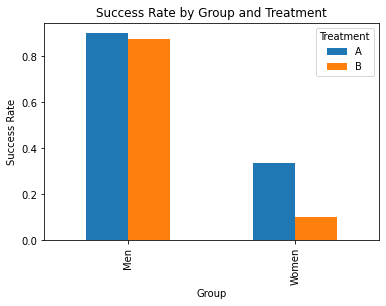

In [20]:
import matplotlib.pyplot as plt

group_plot = data.groupby(["Group","Treatment"])["Success"].mean().unstack()

group_plot.plot(kind="bar")
plt.title("Success Rate by Group and Treatment")
plt.ylabel("Success Rate")
plt.show()

In [ ]:
The paradox occurs because of uneven group distribution:
  Group | Treatment A | Treatment B |
| ----- | ----------- | ----------- |
| Men   | few         | many        |
| Women | many        | few         |

# Simpson's paradox happens when a hidden variable (confounder) changes the interpretation of aggregated data. - GENDER!

In [ ]:
Which treatment is better?

Results show......
Group results → A better
Overall results → B better

How can both be true?

# Gambler's Fallacy

In [ ]:
The Gambler's fallacy is the belief that:

"If something happens many times, the opposite is now more likely."

In [ ]:
Example:

     H H H H H
        
Dont you think Tails is now more likely next ?.

--------------------- > But actually each coin flip is independent.

In [13]:
import numpy as np

flips = np.random.choice(["H","T"], size=20)

print("Coin flips:")
print(flips)

Coin flips:
['H' 'H' 'H' 'H' 'T' 'T' 'T' 'H' 'T' 'T' 'T' 'H' 'T' 'H' 'T' 'H' 'H' 'H'
 'H' 'T']


In [14]:
trials = 100000

heads = np.sum(np.random.choice([0,1], size=trials))

print("Probability of heads:", heads/trials)

Probability of heads: 0.50113


In [ ]:
Notice - result stays close to 0.5 regardless of previous outcomes.

In [16]:
import random

def experiment():

    flips = [random.choice(["H","T"]) for _ in range(6)]

    if flips[:5] == ["H"]*5:
        return flips[5] == "T"

    return None


trials = 100000
count = 0
tails_after = 0

for _ in range(trials):
    
    result = experiment()
    
    if result is not None:
        count += 1
        if result:
            tails_after += 1

print("Probability of tails after 5 heads:", tails_after/count)

Probability of tails after 5 heads: 0.5029373368146214


In [ ]:
# Birthday paradox → intuition failure  
# Monty Hall → conditional probability  
# Gambler's fallacy → independence  
# Simpson's paradox → data interpretation

# A random variable assigns a number to the outcome of an experiment.

In [ ]:
Example: Dice roll.
    
X=outcome of dice roll

In [21]:
import numpy as np

rolls = np.random.randint(1,7,1000)

print("First 10 rolls:", rolls[:10])

First 10 rolls: [3 5 4 4 2 2 6 6 2 2]


# Discrete Random Variables → PMF

In [ ]:

A discrete random variable takes countable values.

Examples:
•	Dice roll
•	Number of emails per hour
•	Number of customers

The Probability Mass Function (PMF) gives the probability of each value.

P(X=x)

| x | P(X=x) |
| - | ------ |
| 1 | 1/6    |
| 2 | 1/6    |
| 3 | 1/6    |
| 4 | 1/6    |
| 5 | 1/6    |
| 6 | 1/6    |


In [22]:
import numpy as np
import pandas as pd

rolls = np.random.randint(1,7,10000)

pmf = pd.Series(rolls).value_counts(normalize=True).sort_index()

print(pmf)

1    0.1672
2    0.1749
3    0.1616
4    0.1670
5    0.1633
6    0.1660
Name: proportion, dtype: float64


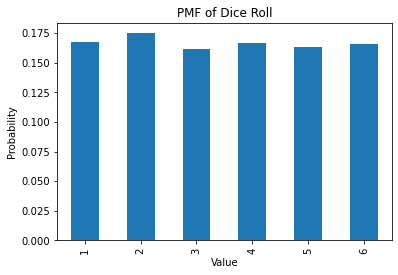

In [23]:
import matplotlib.pyplot as plt

pmf.plot(kind="bar")
plt.title("PMF of Dice Roll")
plt.xlabel("Value")
plt.ylabel("Probability")
plt.show()

# Continuous Random Variables → PDF

In [ ]:
# Continuous Random Variables → PDF

Continuous variables can take any value in a range.

Examples:
•	height
•	temperature
•	time

For these we use a Probability Density Function (PDF).

f(x)

Important property:
P(a≤X≤b)=∫f(x)dx


In [ ]:
# Example: Normal Distribution

## One of the most important distributions is the Normal distribution.

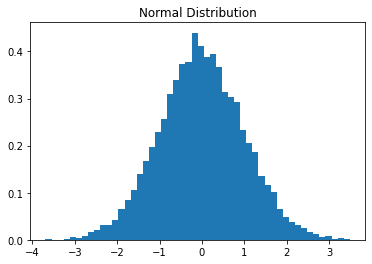

In [24]:
import numpy as np
import matplotlib.pyplot as plt

data = np.random.normal(0,1,10000)

plt.hist(data, bins=50, density=True)
plt.title("Normal Distribution")
plt.show()

In [ ]:
# This histogram approximates the PDF.

# Cumulative Distribution Function (CDF)

In [ ]:
The CDF gives the probability that a variable is less than or equal to a value.

    F(x)=P(X≤x)

Properties:
•	ranges from 0 → 1
•	always increasing


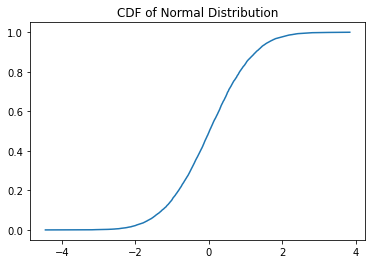

In [25]:
import numpy as np
import matplotlib.pyplot as plt

data = np.random.normal(0,1,10000)

sorted_data = np.sort(data)
cdf = np.arange(len(data))/len(data)

plt.plot(sorted_data, cdf)
plt.title("CDF of Normal Distribution")
plt.show()

# Conditional Probability

In [ ]:
Conditional probability tells us:
        What is the probability of event A given that B has already happened?

P(A∣B)= P(A∩B) /  P(B)


In [ ]:
## Example

|        | Pass | Fail |
| ------ | ---- | ---- |
| Male   | 40   | 10   |
| Female | 30   | 20   |


In [26]:
import pandas as pd

data = {
    "Male":[40,10],
    "Female":[30,20]
}

df = pd.DataFrame(data, index=["Pass","Fail"])

print(df)

      Male  Female
Pass    40      30
Fail    10      20


In [27]:
P_pass_given_male = 40/(40+10)

print(P_pass_given_male)

0.8


In [ ]:
# Another example 

Example: probability of rolling a 4 given the roll is even.

In [28]:
import numpy as np

rolls = np.random.randint(1,7,100000)

even_rolls = rolls[rolls%2==0]

prob = np.sum(even_rolls==4)/len(even_rolls)

print(prob)

0.3375166835992749


In [ ]:
# PMF vs PDF

| Feature     | PMF         | PDF              |
| ----------- | ----------- | ---------------- |
| Type        | Discrete    | Continuous       |
| Function    | P(X=x)      | f(x)             |
| Probability | Exact value | Area under curve |
| Example     | dice        | height           |


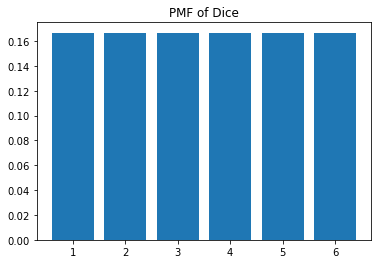

In [29]:
values = [1,2,3,4,5,6]
prob = [1/6]*6

plt.bar(values,prob)
plt.title("PMF of Dice")
plt.show()

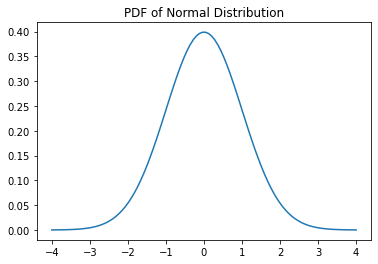

In [30]:
import numpy as np

x = np.linspace(-4,4,100)
y = (1/np.sqrt(2*np.pi))*np.exp(-x**2/2)

plt.plot(x,y)
plt.title("PDF of Normal Distribution")
plt.show()

In [ ]:
Probability
↓
Random Variable
We convert outcomes into numbers.
↓
Discrete → PMF
Continuous → PDF
Depending on the type of random variable:
( discrete → PMF; continuous → PDF)
↓
CDF
CDF accumulates probabilities from the PMF or PDF.


In [ ]:
# Joint Probability

In [ ]:
Joint probability measures the probability of two events happening together.

P(A,B)

Example:
•	A = student studies
•	B = student passes

P(A,B)=probability student studies AND passes

In [31]:
import numpy as np

# simulate study (1=yes,0=no)
study = np.random.choice([0,1], size=1000)

# simulate pass depending on study
pass_exam = np.where(study==1,
                     np.random.choice([0,1],1000,p=[0.2,0.8]),
                     np.random.choice([0,1],1000,p=[0.7,0.3]))

joint = np.mean((study==1) & (pass_exam==1))

print("P(Study AND Pass):", joint)

P(Study AND Pass): 0.415


In [ ]:
# Conditional Probability - 

P(A∣B)= P(A,B)/P(B)

P(Class∣Data)   ?? --- Isnt this What ML Does ?


In [ ]:
# Bayes' Theorem

One of the most important equations in ML.
 
P(A∣B)= P(B∣A)P(A) / P(B)

P(A∣B)   Posterior
P(A)     Prior
P(B)     Evidence
P(B∣A)   Likelihood

In [ ]:
prior = 0.01
likelihood = 0.9
evidence = 0.1

posterior = (likelihood * prior) / evidence

print(posterior)


In [ ]:
# Independence

Two events are independent if: P(A,B)=P(A)P(B)
    
The algorithm assumes features are independent:
                        P(x1,x2,x3∣y)=P(x1∣y)P(x2∣y)P(x3∣y) 
        
Even though this assumption is often not perfectly true, the method works surprisingly well.


In [ ]:
Expectation (Expected Value)

Expectation is the average value of a random variable.

E[X]=∑xP(x)
or
E[X]=∫xf(x)dx


In [32]:
# Expected Value (Mean): Long-term average outcome of a random variable.
# Variance: Measures spread (how far values deviate from the mean).

# # E(X)=∑xP(x)
# # Var(X)=E(X2)−(E(X))2

# Example: Expected Value & Variance of a Die

# Possible outcomes
x = np.array([1, 2, 3, 4, 5, 6])
p = np.ones(6) / 6  # Equal probability

# Expected Value
expected_value = np.sum(x * p)

# Variance
variance = np.sum((x**2) * p) - expected_value**2

print(f"Expected Value (Mean) = {expected_value:.2f}")
print(f"Variance = {variance:.2f}")

# The average roll of a die is 3.5, even though 3.5 never actually occurs!

Expected Value (Mean) = 3.50
Variance = 2.92


In [33]:
# Variance
## Variance measures uncertainty or spread.

import numpy as np

data = np.random.normal(0,1,1000)

print(np.var(data))

# Variance plays a big role in:
#     Gaussian models
#     bias–variance tradeoff

0.9828811154855858


In [ ]:
# Covariance and Correlation

# Covariance 

Covariance measures how two variables change together.

Cov(X,Y)

In [34]:
import numpy as np

x = np.random.normal(0,1,1000)
y = 2*x + np.random.normal(0,0.5,1000)

print(np.cov(x,y))

[[0.98468048 1.96796669]
 [1.96796669 4.1718838 ]]


In [ ]:
Correlation:

ρ=Cov(X,Y) / σx σy

Used in:

    feature analysis
    dimensionality reduction
    regression

In [ ]:
# 

Important Probability Distributions 

# Bernoulli Distribution
Binary outcome.
Example:
spam / not spam

# Binomial Distribution
Number of successes in multiple trials.
Example:
number of clicks

# Gaussian Distribution
Most common continuous distribution.
Used in:
•	Gaussian Naive Bayes
•	generative models
•	noise models

# Poisson Distribution
Models count events over time.
Example:
•	website traffic
•	call arrivals



In [ ]:
# Maximum Likelihood Estimation (MLE)

MLE is how ML models learn parameters.

    We choose parameters that maximize the probability of observed data.
            θ* =  arg max 𝑃(𝐷𝑎𝑡𝑎∣𝜃)

Example: estimating mean of Gaussian.

In [35]:
import numpy as np

data = np.random.normal(5,2,1000)

mle_mean = np.mean(data)

print(mle_mean)

4.999302600964075


In [ ]:
# Law of Large Numbers

As the number of samples increases:

                            sample mean → true mean
Important for:

    training models
    Monte Carlo simulations

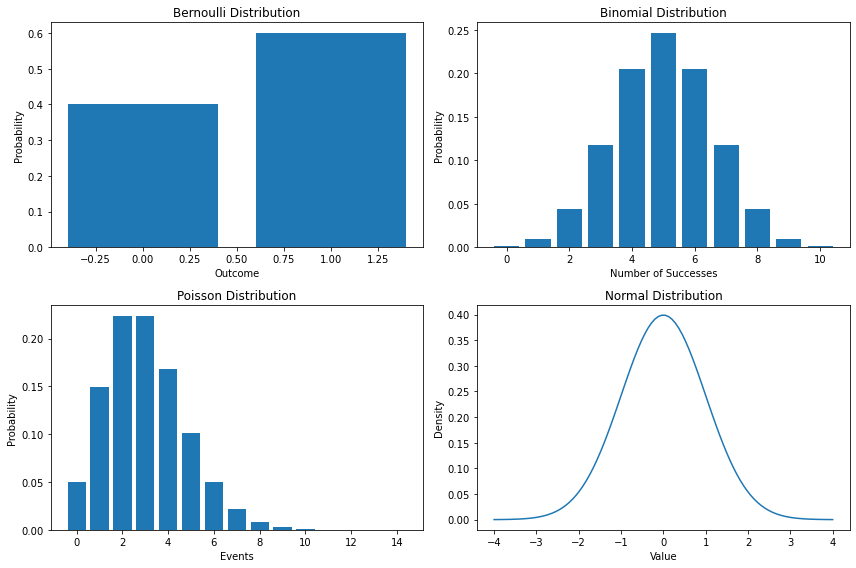

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli, binom, poisson, norm

fig, axes = plt.subplots(2, 2, figsize=(12,8))

# ----------------------
# Bernoulli Distribution
# ----------------------
p = 0.6
x = [0,1]
y = bernoulli.pmf(x,p)

axes[0,0].bar(x,y)
axes[0,0].set_title("Bernoulli Distribution")
axes[0,0].set_xlabel("Outcome")
axes[0,0].set_ylabel("Probability")


# ----------------------
# Binomial Distribution
# ----------------------
n = 10
p = 0.5
x = np.arange(0,n+1)
y = binom.pmf(x,n,p)

axes[0,1].bar(x,y)
axes[0,1].set_title("Binomial Distribution")
axes[0,1].set_xlabel("Number of Successes")
axes[0,1].set_ylabel("Probability")


# ----------------------
# Poisson Distribution
# ----------------------
lam = 3
x = np.arange(0,15)
y = poisson.pmf(x,lam)

axes[1,0].bar(x,y)
axes[1,0].set_title("Poisson Distribution")
axes[1,0].set_xlabel("Events")
axes[1,0].set_ylabel("Probability")


# ----------------------
# Normal Distribution
# ----------------------
x = np.linspace(-4,4,100)
y = norm.pdf(x,0,1)

axes[1,1].plot(x,y)
axes[1,1].set_title("Normal Distribution")
axes[1,1].set_xlabel("Value")
axes[1,1].set_ylabel("Density")


plt.tight_layout()
plt.show()

In [ ]:
| Distribution | Type       | Used For          |
| ------------ | ---------- | ----------------- |
| Bernoulli    | Discrete   | binary events     |
| Binomial     | Discrete   | repeated trials   |
| Poisson      | Discrete   | event counts      |
| Normal       | Continuous | natural variation |
